# Quant CSOT — Week 3 Challenge

Complete the `get_weights` function below, then run the backtest cells to
check your strategy against the portfolio constraints and see its Sharpe
ratio. See `docs/competition_rules.md`, `docs/evaluation.md`, and
`docs/submission_format.md` for the full task description.

**Before running:** download `features.parquet`, `universe.parquet`, and
`returns.parquet` into the `data/` folder. Instructions are in
`data/download_data.md`.


In [1]:
# Install gdown for downloading files from Google Drive
!pip install gdown -q

In [2]:
# Create the 'data/' directory if it doesn't exist
import os
if not os.path.exists('data'):
    os.makedirs('data')
    print("Created 'data/' directory.")
else:
    print("'data/' directory already exists.")

Created 'data/' directory.


In [3]:
import os

# Install gdown if it isn't already
!pip install gdown -q

# Create the data directory
os.makedirs('data', exist_ok=True)

# Download the TRUE Universe file (The 1.1 MB mask)
!gdown --id 1fcOeGk0OL6xw7tWq9MsdKbaut47u9eTa -O data/universe.parquet

# Download the TRUE Returns file (The 55 MB floats)
!gdown --id 1tZ7OoGvs7hm_soSYBYNZYhUk3g4QzlFt -O data/returns.parquet

print("✓ Correct files successfully downloaded from Google Drive!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1fcOeGk0OL6xw7tWq9MsdKbaut47u9eTa
To: /kaggle/working/data/universe.parquet
100%|██████████████████████████████████████| 1.19M/1.19M [00:00<00:00, 62.8MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1tZ7OoGvs7hm_soSYBYNZYhUk3g4QzlFt
To: /kaggle/working/data/returns.parquet
100%|██████████████████████████████████████| 55.6M/55.6M [00:01<00:00, 37.9MB/s]
✓ Correct files successfully downloaded from Google Drive!


In [4]:
# Download features.parquet
!gdown --id 1cp--e02t83bcRu9Umuvv6973l7IUexlg -O data/features.parquet
print("Downloaded features.parquet")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1cp--e02t83bcRu9Umuvv6973l7IUexlg
From (redirected): https://drive.google.com/uc?id=1cp--e02t83bcRu9Umuvv6973l7IUexlg&confirm=t&uuid=e52892dc-92d4-4c46-b767-2764a0fd5c8d
To: /kaggle/working/data/features.parquet
100%|██████████████████████████████████████| 1.69G/1.69G [00:23<00:00, 70.9MB/s]
Downloaded features.parquet


In [5]:
# Clone the GitHub repository containing the 'src' folder
!git clone https://github.com/Priyesha710/CSOT-Quant.git
print("GitHub repository cloned.")

Cloning into 'CSOT-Quant'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 132 (delta 35), reused 87 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 326.40 KiB | 9.07 MiB/s, done.
Resolving deltas: 100% (35/35), done.
GitHub repository cloned.


Once Google Drive is mounted, you can access your files at `/content/drive/MyDrive/`. Please provide the specific paths to `features.parquet`, `universe.parquet`, and `returns.parquet` within your mounted Drive folder. Alternatively, you can generate shareable links for each file and I can help you download them directly.

In [6]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set REPO_ROOT to the cloned repository path
REPO_ROOT = Path("/kaggle/working/CSOT-Quant").resolve()

# Append the specific src directory to sys.path
sys.path.append(str(REPO_ROOT / "week-3" / "Week 3" / "src"))

import utils

## 1. Load data

In [7]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

print("Loading universe and returns...")
universe = pd.read_parquet('data/universe.parquet')
returns = pd.read_parquet('data/returns.parquet')

print("Loading features efficiently with PyArrow...")
# NOTE: Ensure this path correctly points to where features.parquet is saved in Kaggle!
table = pq.read_table('data/features.parquet') 
features = table.to_pandas(types_mapper={np.float64: np.float32}.get)

del table
import gc
gc.collect()

print("features:", features.shape, " (rows=dates, columns=(feature, stock_id))")

universe.columns = universe.columns.astype(str)
returns.columns = returns.columns.astype(str)
features.columns = features.columns.set_levels(
    features.columns.levels[1].astype(str), level=1
)

print("Data successfully loaded and types unified!")

Loading universe and returns...
Loading features efficiently with PyArrow...
features: (5058, 47674)  (rows=dates, columns=(feature, stock_id))
Data successfully loaded and types unified!


In [8]:
features.head()


macd                                                      \
                   1         2   3         4         5         6   7   8   
Date                                                                       
2005-01-03  0.000000  0.000000 NaN  0.000000  0.000000  0.000000 NaN NaN   
2005-01-04 -0.004732 -0.013272 NaN -0.000149 -0.002068  0.000122 NaN NaN   
2005-01-05 -0.007316 -0.024657 NaN -0.000298 -0.002582  0.000294 NaN NaN   
2005-01-06 -0.012633 -0.029492 NaN -0.000696 -0.003024  0.000432 NaN NaN   
2005-01-07 -0.017653 -0.024735 NaN -0.001319 -0.005041  0.001372 NaN NaN   

                                ... chande_momentum_oscillator                 \
                   9        10  ...                       2158 2159 2160 2161   
Date                            ...                                             
2005-01-03  0.000000  0.000000  ...                        NaN  NaN  NaN  NaN   
2005-01-04 -0.002817 -0.000112  ...                        NaN  NaN  NaN  NaN   
2005-01-05 -0.009337  0.002122  ...                        NaN  NaN  NaN  NaN   
2005-01-06 -0.011318  0.005346  ...                        NaN  NaN  NaN  NaN   
2005-01-07 -0.013881  0.009659  ...                        NaN  NaN  NaN  NaN   

                                          
           2162 2163 2164 2165 2166 2167  
Date                                      
2005-01-03  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-04  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-05  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-06  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-07  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 47674 columns]

In [9]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
feature_names = features.columns.get_level_values(0).unique().tolist()
stock_ids     = features.columns.get_level_values(1).unique().tolist()

print(f"Features : {len(feature_names)}")
print(f"Stocks   : {len(stock_ids)}")
print(f"Dates    : {len(features)} ({features.index[0].date()} → {features.index[-1].date()})")
print(f"Universe : {universe.sum(axis=1).mean():.0f} stocks/day avg")
print(f"\nFeature list: {feature_names}")

# Check missingness on the latest snapshot
snap = features.iloc[-1].unstack(level=0)  # stock_id × feature_name
print("\nMissing % per feature (last day):")
print((snap.isnull().mean() * 100).sort_values(ascending=False).to_string())

Features : 22
Stocks   : 2167
Dates    : 5058 (2005-01-03 → 2025-02-07)
Universe : 996 stocks/day avg

Feature list: ['macd', 'trend_1_3', 'trend_5_20', 'trend_20_60', 'aroon', 'trix', 'ichimoku', 'know_sure_thing', 'average_true_range', 'volatility_20', 'volatility_60', 'on_balance_volume', 'ease_of_movement', 'accumulation_distribution_index', 'chaikin_money_flow', 'relative_strength_index', 'stochastic_oscillator', 'williams_r', 'volume', 'commodity_channel_index', 'ultimate_oscillator', 'chande_momentum_oscillator']

Missing % per feature (last day):
chaikin_money_flow                 1.107522
accumulation_distribution_index    0.922935
ease_of_movement                   0.784495
chande_momentum_oscillator         0.646054
ultimate_oscillator                0.507614
williams_r                         0.461467
stochastic_oscillator              0.461467
commodity_channel_index            0.230734
average_true_range                 0.000000
aroon                              0.000000

In [11]:
print("Universe shape:", universe.shape)
print("Universe data types:", universe.dtypes.value_counts())
print("\nUnique values in a sample of the data:")
print(pd.unique(universe.iloc[:100, :100].values.ravel()))

print("\nValue counts for a random day (Day 500):")
print(universe.iloc[500].value_counts(dropna=False))

Universe shape: (5058, 2167)
Universe data types: int32    2167
Name: count, dtype: int64

Unique values in a sample of the data:
[0 1]

Value counts for a random day (Day 500):
2006-12-27 00:00:00
0    1167
1    1000
Name: count, dtype: int64


In [12]:
import gc
import numpy as np
import pandas as pd

# ── 1. FOOLPROOF TYPE SYNCHRONIZATION ────────
universe.columns = universe.columns.astype(float).astype(int).astype(str)
returns.columns = returns.columns.astype(float).astype(int).astype(str)

features.columns = pd.MultiIndex.from_arrays([
    features.columns.get_level_values(0),
    features.columns.get_level_values(1).astype(float).astype(int).astype(str)
])

# ── 2. FOOLPROOF TYPE SYNCHRONIZATION (ROWS/DATES) ───────────────
features.index = pd.to_datetime(features.index, utc=True).tz_convert(None).normalize()
universe.index = pd.to_datetime(universe.index, utc=True).tz_convert(None).normalize()
returns.index  = pd.to_datetime(returns.index,  utc=True).tz_convert(None).normalize()

features = features[~features.index.duplicated(keep='last')]
universe = universe[~universe.index.duplicated(keep='last')]
returns  = returns[~returns.index.duplicated(keep='last')]
print("✓ Dates and IDs flawlessly synchronized.")

# ── 3. ROBUST UNSTACK CHECK & TRAINING ───────────────────────────
def _get_unstack_level(features, universe):
    for i in range(1, 50):
        tradable = universe.iloc[-i][universe.iloc[-i] == 1].index
        if len(tradable) > 0:
            snap = features.iloc[-i].unstack(level=0)
            if snap.index.isin(tradable).sum() > 0:
                return 0
            snap = features.iloc[-i].unstack(level=1)
            if snap.index.isin(tradable).sum() > 0:
                return 1
    raise ValueError("Cannot align snap.index with tradable stocks. Check data types.")

def build_training_data(features, returns, universe, lag=1, sample_every=1):
    feat_names   = features.columns.get_level_values(0).unique().tolist()
    dates        = features.index[:-lag]
    fwd_ret      = returns.shift(-lag)
    ulevel       = _get_unstack_level(features, universe)

    if ulevel == 1:
        feat_names = features.columns.get_level_values(1).unique().tolist()

    X_list, y_list = [], []

    for i, t in enumerate(dates):
        if i % sample_every != 0: continue
        if t not in fwd_ret.index or t not in universe.index: continue

        tradable = universe.loc[t]
        tradable = tradable[tradable == 1].index  # Pure binary check!

        if len(tradable) < 5: continue

        snap  = features.loc[t].unstack(level=ulevel)
        snap  = snap.loc[snap.index.isin(tradable)]
        if len(snap) < 5: continue

        ret_t = fwd_ret.loc[t].reindex(snap.index).dropna()
        snap  = snap.loc[ret_t.index]
        if len(snap) < 5: continue

        X_t = snap.reindex(columns=feat_names).fillna(0).values.astype('float32')
        mu   = X_t.mean(axis=0)
        std  = X_t.std(axis=0) + 1e-8
        X_t  = (X_t - mu) / std

        y_t = ret_t.rank(pct=True).values.astype('float32') - 0.5

        X_list.append(X_t)
        y_list.append(y_t)

        if i % 1000 == 0:
            print(f"  {i}/{len(dates)} dates processed...")

    if len(X_list) == 0:
        raise ValueError("All dates skipped.")

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    del X_list, y_list
    gc.collect()

    print(f"Training data: {X.shape[0]:,} samples × {X.shape[1]} features")
    return X, y, feat_names

# Recommend sample_every=5 to save RAM
# Bottom of Cell 14 — change this line only
X_cs, y_cs, FEATURE_COLS = build_training_data(features, returns, universe, sample_every=5, lag=5)

✓ Dates and IDs flawlessly synchronized.
  1000/5053 dates processed...
  2000/5053 dates processed...
  3000/5053 dates processed...
Training data: 750,000 samples × 22 features


In [13]:
n = len(X_cs)
val_start = int(n * 0.6)
val_end   = int(n * 0.8)

X_tr = np.concatenate([X_cs[:val_start], X_cs[val_end:]])
y_tr = np.concatenate([y_cs[:val_start], y_cs[val_end:]])
X_va = X_cs[val_start:val_end]
y_va = y_cs[val_start:val_end]

print(f"Train: {len(X_tr):,} rows (60% early + 20% late)")
print(f"Val  : {len(X_va):,} rows (middle 20%, ~2017–2020)")

Train: 600,000 rows (60% early + 20% late)
Val  : 150,000 rows (middle 20%, ~2017–2020)


In [14]:
X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
X_va = np.nan_to_num(X_va, nan=0.0, posinf=0.0, neginf=0.0)

print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,          # raised ceiling — early stopping finds true optimum
    learning_rate=0.03,
    max_depth=4,      num_leaves=31,   # was 15
    min_child_samples=20,
    subsample=0.8,    colsample_bytree=0.7,
    reg_alpha=0.1,    reg_lambda=0.1,
    random_state=42,  n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=True),
               lgb.log_evaluation(50)]
)
best_iter = lgb_model.best_iteration_
print(f"\nOptimal trees: {best_iter}")

print("\nTraining Ridge...")
ridge_model = Ridge(alpha=100)
ridge_model.fit(X_tr, y_tr)

fi = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)
print("\nTop features by importance:")
print(fi.sort_values(ascending=False).head(10))

Training LightGBM...
Training until validation scores don't improve for 40 rounds
[50]	valid_0's l2: 0.0833251
Early stopping, best iteration is:
[17]	valid_0's l2: 0.0833222

Optimal trees: 17

Training Ridge...

Top features by importance:
ease_of_movement         82
volatility_60            32
volatility_20            31
ichimoku                 21
average_true_range       17
on_balance_volume        11
stochastic_oscillator     9
trend_20_60               9
trend_1_3                 6
aroon                     6
dtype: int32


In [15]:
from scipy.stats import spearmanr

p_lgb = lgb_model.predict(X_va)
p_rdg = ridge_model.predict(X_va)
p_ens = 0.6 * p_lgb + 0.4 * p_rdg

print("Validation Spearman IC vs ranked target:")
for name, pred in [('LightGBM', p_lgb), ('Ridge', p_rdg), ('Ensemble', p_ens)]:
    ic, pval = spearmanr(pred, y_va)
    print(f"  {name:12s}  IC={ic:.4f}  p={pval:.3f}")

Validation Spearman IC vs ranked target:
  LightGBM      IC=0.0146  p=0.000
  Ridge         IC=0.0229  p=0.000
  Ensemble      IC=0.0236  p=0.000


In [16]:
# ── PHASE 1: honest OOS evaluation ────────────────────────────────────────
# Train only on first 80% of dates → evaluate on last 20% (true OOS)
X_cs = np.nan_to_num(X_cs, nan=0.0, posinf=0.0, neginf=0.0)  # ← add this
print("Training OOS evaluation model (80% of data)...")
LGB_OOS = lgb.LGBMRegressor(
    n_estimators=best_iter, learning_rate=0.03,
    max_depth=4, num_leaves=31, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
LGB_OOS.fit(X_tr, y_tr)   # X_tr = first 80% only

RIDGE_OOS = Ridge(alpha=100)
RIDGE_OOS.fit(X_tr, y_tr)

# Quick OOS IC check
from scipy.stats import spearmanr
p_oos = 0.6 * LGB_OOS.predict(X_va) + 0.4 * RIDGE_OOS.predict(X_va)
ic, pval = spearmanr(p_oos, y_va)
print(f"True OOS IC = {ic:.4f}  (p={pval:.3f})")
print("^ This is your honest signal quality estimate\n")

# ── PHASE 2: final submission model (all data, no leakage for test period) ─
# Safe to use all data because competition test is AFTER 2025-02-07
print(f"Training Final model on ALL data (n_estimators={best_iter})...")
LGB_FINAL = lgb.LGBMRegressor(
    n_estimators=best_iter, learning_rate=0.03,
    max_depth=4, num_leaves=31, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
LGB_FINAL.fit(X_cs, y_cs)

RIDGE_FINAL = Ridge(alpha=100)
RIDGE_FINAL.fit(X_cs, y_cs)
print("Done. LGB_FINAL and RIDGE_FINAL ready for backtest.")

Training OOS evaluation model (80% of data)...
True OOS IC = 0.0236  (p=0.000)
^ This is your honest signal quality estimate

Training Final model on ALL data (n_estimators=17)...
Done. LGB_FINAL and RIDGE_FINAL ready for backtest.


## 2. Implement your strategy

`get_weights` is called once per trading day. It receives:

- `features`: every feature's full history **strictly before** today (no look-ahead)
- `today_universe`: a 0/1 Series telling you which stocks can be traded today

It must return a `dict[str, float]` mapping stock id -> weight, containing
**only** stock ids where `today_universe` is `1`.

Keep the portfolio constraints in mind (see `docs/competition_rules.md`):
- `sum(|w|) <= 1 + 1e-4`
- `|w| <= 0.1` per stock
- `|sum(w)| <= 1e-4` (dollar neutral)


In [17]:
_SIGNAL_STATE = {'prev': None}
UNSTACK_LEVEL = _get_unstack_level(features, universe)

def get_weights(features: pd.DataFrame, today_universe: pd.Series) -> dict[str, float]:

    tradable = today_universe[today_universe == 1].index.astype(str).tolist()

    # ── BUG #1 FIX: reset signal state at the start of every backtest run ──
    # len(features)==0 only on the very first day — safe reset point
    if len(features) == 0:
        _SIGNAL_STATE['prev'] = None
        return {s: 0.0 for s in tradable}

    if len(tradable) < 4:
        return {s: 0.0 for s in tradable}

    # ── Feature extraction ─────────────────────────────────────────────────
    latest = features.iloc[-1]
    try:
        cross = latest.unstack(level=UNSTACK_LEVEL)
    except Exception:
        return {s: 0.0 for s in tradable}

    cross = cross[cross.index.isin(set(tradable))]
    if len(cross) < 4:
        return {s: 0.0 for s in tradable}

    X = pd.DataFrame(index=cross.index)
    for fn in FEATURE_COLS:
        X[fn] = cross[fn] if fn in cross.columns else 0.0
    X = X.fillna(0.0)

    mu, sig = X.mean(), X.std() + 1e-8
    X_cs = (X - mu) / sig
    X_cs = X_cs.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    # ── Model inference ────────────────────────────────────────────────────
    try:
        alphas = 0.6 * LGB_FINAL.predict(X_cs) + 0.4 * RIDGE_FINAL.predict(X_cs)
    except Exception:
        return {s: 0.0 for s in tradable}

    alpha_s = pd.Series(alphas, index=cross.index)

    # ── Signal smoothing ───────────────────────────────────────────────────
    if _SIGNAL_STATE['prev'] is not None:
        prev = _SIGNAL_STATE['prev'].reindex(alpha_s.index).fillna(0.0)
        alpha_s = 0.7 * alpha_s + 0.3 * prev
    _SIGNAL_STATE['prev'] = alpha_s.copy()

    # ── Portfolio construction ─────────────────────────────────────────────
    n = len(alpha_s)
    n_each = max(2, min(10, n // 5))

    long_candidates  = alpha_s.nlargest(n_each).index
    short_candidates = alpha_s.nsmallest(n_each).index

    longs  = set(long_candidates) - set(short_candidates)
    shorts = set(short_candidates) - set(long_candidates)

    # ── BUG #3 FIX: size on smaller side so gross capacity is never wasted ─
    n_side = max(1, min(len(longs), len(shorts)))
    w = min(0.1, 0.5 / n_side)             # was: 0.5 / max(1, len(longs))

    weights = {s: 0.0 for s in tradable}
    for s in longs:  weights[s] =  w
    for s in shorts: weights[s] = -w

    # ── Dollar-neutral scaling ─────────────────────────────────────────────
    pos_sum = sum(v for v in weights.values() if v > 0)
    neg_sum = sum(abs(v) for v in weights.values() if v < 0)
    target  = min(pos_sum, neg_sum)

    if target > 0:
        for s, v in weights.items():
            if v > 0: weights[s] = v * (target / pos_sum)
            elif v < 0: weights[s] = v * (target / neg_sum)
    else:
        return {s: 0.0 for s in tradable}

    # ── BUG #2 FIX: distribute residual evenly — no single weight can spike ─
    net = sum(weights.values())
    if abs(net) > 1e-9:
        nonzero = [s for s, v in weights.items() if v != 0.0]
        if nonzero:
            adj = net / len(nonzero)        # was: subtract full net from one stock
            for s in nonzero:
                weights[s] -= adj

    return weights

## 3. Backtest

In [18]:
weights = utils.backtest_strategy(get_weights, features, universe)
weights.head()


Backtesting: 100%|██████████| 5058/5058 [37:43<00:00,  2.23it/s]


,1,2,3,4,5,6,7,8,9,10,...,2158,2159,2160,2161,2162,2163,2164,2165,2166,2167
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Validate constraints

In [19]:
checks = utils.validate_weights(weights, universe)
for name, passed in checks.items():
    print(f"{name:20s} {'PASS' if passed else 'FAIL'}")


unit_capital         PASS
max_weight           PASS
dollar_neutral       PASS
universe_respected   PASS


## 5. Score the strategy (training period only)

In [20]:
metrics = utils.summarize_performance(weights, returns)
for k, v in metrics.items():
    print(f"{k:16s} {v:.4f}")


turnover_pct     72.2985
gross_sharpe     -0.4135
net_sharpe       -0.4884
mean_book_value  0.9960


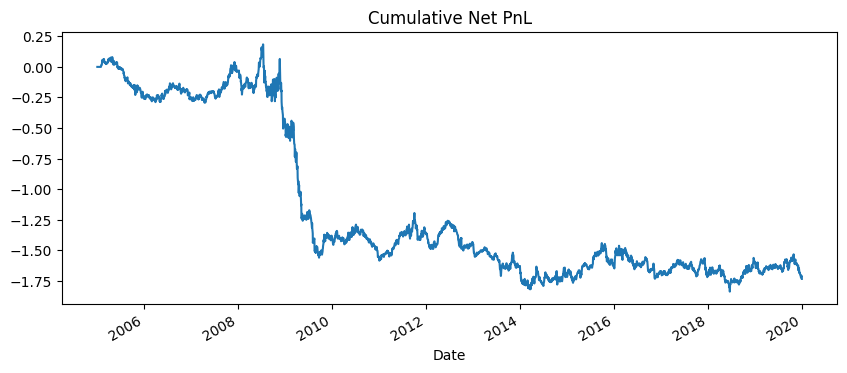

In [21]:
net_pnl = utils.net_pnl(weights, returns)
net_pnl.cumsum().plot(figsize=(10, 4), title="Cumulative Net PnL")
plt.show()


## 6. Export submission

`submission.csv` is saved to the repo root and must have the same shape and
index as `data/universe.parquet`. Run `src/validate_submission.py` from the
repo root to double check before you submit (see `docs/submission_format.md`).


In [22]:
output_path = REPO_ROOT / "submission.csv"
weights.to_csv(output_path)
print("Saved", output_path, "with shape", weights.shape)


Saved /kaggle/working/CSOT-Quant/submission.csv with shape (5058, 2167)
